# MNIST findings

## Low-data continual learning with compressed Fisher memory

A pretrained model is valuable because it already contains information. This work asks how an online learner can reuse that information while adapting to a new task with **small batches, bounded memory, and modest hardware**.

The controlled MNIST environment gradually increases the prevalence of digit 9. The experiment is deliberately simple enough to measure carefully, but it represents a broader deployment question: can a high-quality starter model learn a specialized task without retaining or repeatedly optimizing over its entire training history?

> **Primary conclusion.** EWC-compressed history substantially improves low-data continual learning. In the tested regime, the practical recipe is a rank-8-plus-diagonal Fisher estimate maintained by direct exponential averaging, optionally paired with a small replay buffer.

The sections below load only accepted immutable artifacts. Detailed theory lives in the [mathematical overview](mathematical_overview.ipynb); exact treatment semantics and provenance live in [experimental conditions](mnist_experiment/EXPERIMENTAL_CONDITIONS.md).

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(
    (
        path
        for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (path / "src").is_dir() and (path / "mnist_experiment").is_dir()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError("Could not locate the amari-chenstov-updates repository root")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.results_analysis import (
    load_phase4_run,
    load_phase7_coupled_run,
    load_phase7_fixed_run,
    normalized_phase4_condition_rows,
    phase4_replica_summaries,
    phase7_coupled_rows,
    phase7_coupled_summaries,
    phase7_fixed_rows,
    phase7_fixed_summaries,
)

def completed_json(relative_directory, filename="summary.json"):
    directory = ROOT / relative_directory
    if not (directory / "COMPLETED").is_file():
        raise FileNotFoundError(f"Completed artifact required: {directory}")
    return json.loads((directory / filename).read_text(encoding="utf-8"))

DEPLOYMENT_DIR = Path(
    "cache/mnist_experiment/plan3/analysis/"
    "phase7__plan3-fresh-confirmation__r0011-r0025__89c1451b1983__n10__85db75d1349e"
)
DEPLOYMENT = completed_json(DEPLOYMENT_DIR)
if DEPLOYMENT.get("schema_version") != 1:
    raise RuntimeError("Unsupported Plan 3 confirmation schema")

FIXED_REPRESENTATION_DIR = ROOT / (
    "cache/mnist_experiment/phase7_runs/"
    "mnist_lfu_phase7_rank_pilot__replica-0000__14916102ebf92cc3"
)
COUPLED_REPRESENTATION_DIR = ROOT / (
    "cache/mnist_experiment/phase7_runs/"
    "mnist_lfu_phase7_coupled_rank8__replica-0000__b0f9fdc792134eb9"
)
fixed_run = load_phase7_fixed_run(FIXED_REPRESENTATION_DIR)
coupled_run = load_phase7_coupled_run(COUPLED_REPRESENTATION_DIR)
fixed_summary = pd.DataFrame(
    phase7_fixed_summaries(phase7_fixed_rows([fixed_run]))
)
coupled_summary = pd.DataFrame(
    phase7_coupled_summaries(phase7_coupled_rows([coupled_run]))
)

LFU_RUN_DIRS = [
    ROOT / "cache/mnist_experiment/runs/mnist_lfu_phase5_k9_m64__replica-0000__5b7be59b7c87f6aa",
    ROOT / "cache/mnist_experiment/runs/mnist_lfu_phase5_k9_m128__replica-0000__1c3020348d62e0e8",
    ROOT / "cache/mnist_experiment/runs/mnist_lfu_phase5_k21_m64__replica-0000__15143966ddd1b113",
    ROOT / "cache/mnist_experiment/runs/mnist_lfu_phase4_ridge_pilot__replica-0000__8294cf954c52cb00",
]
lfu_runs = [load_phase4_run(path) for path in LFU_RUN_DIRS]
lfu_tracking = pd.DataFrame(
    phase4_replica_summaries(normalized_phase4_condition_rows(lfu_runs))
)

NO_LFU_METRICS = completed_json(
    Path("cache/mnist_experiment/phase8_runs/")
    / "mnist_lfu_plan2-low-data_m008_fixed-ewc-pi005__replica-0006__7fe95bcd213baccf",
    "phase8_metrics.json",
)
AC_LFU_METRICS = completed_json(
    Path("cache/mnist_experiment/plan3_runs/")
    / "mnist_lfu_plan3-phase5_ewc-fixed005-ac-only__replica-0006__582a94e1fecda157",
    "phase8_metrics.json",
)
FULL_LFU_METRICS = completed_json(
    Path("cache/mnist_experiment/plan3_runs/")
    / "mnist_lfu_plan3-phase5_ewc-fixed005-full-lfu__replica-0006__8a989eb60ffa6b0b",
    "phase8_metrics.json",
)

FLOOR = completed_json(
    Path("cache/mnist_experiment/plan4/challenge/floor_analysis/")
    / "floor_sensitivity__b022b149d154"
)
DISCOVERY = completed_json(
    Path("cache/mnist_experiment/plan4/edr/discovery/analysis/")
    / "edr_discovery__7b14c111ed7b"
)
STRESS = completed_json(
    Path("cache/mnist_experiment/plan4/edr/stress/analysis/")
    / "edr_stress__8f56773be109"
)

COLORS = {
    "current": "#B94A48",
    "ewc": "#007C91",
    "replay": "#D97706",
    "hybrid": "#2E7D32",
    "unbounded": "#6B4C9A",
    "dense": "#355C8A",
    "rank8": "#2E7D32",
    "diagonal": "#B94A48",
    "lfu": "#8B5E9A",
    "ridge": "#D97706",
}
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#273142",
    "axes.titlecolor": "#111827",
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "font.size": 10,
    "legend.frameon": False,
    "grid.color": "#D1D5DB",
    "grid.alpha": 0.45,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

LABELS = {
    "confirm-current-only": "Current batch only",
    "confirm-ewc-fixed005": "EWC, pi=.05",
    "confirm-hybrid-b032-fixed005": "Hybrid B32",
    "confirm-replay-b032": "Replay B32",
    "confirm-replay-unbounded": "Unbounded replay",
}
CONDITION_COLORS = {
    "confirm-current-only": COLORS["current"],
    "confirm-ewc-fixed005": COLORS["ewc"],
    "confirm-hybrid-b032-fixed005": COLORS["hybrid"],
    "confirm-replay-b032": COLORS["replay"],
    "confirm-replay-unbounded": COLORS["unbounded"],
}

def expected_rows(condition, *, maximum_p=0.5):
    return sorted(
        (
            row
            for row in DEPLOYMENT["expected_trajectories"]
            if (
                row["condition"] == condition
                and row["p"] < maximum_p
                and row["step"] > 0
            )
        ),
        key=lambda row: row["p"],
    )

def plot_expected(axis, condition, metric, *, x_field="expected_nines_before_evaluation"):
    rows = expected_rows(condition)
    x = np.asarray([row[x_field] for row in rows], dtype=float)
    center = np.asarray([row[metric]["mean"] for row in rows], dtype=float)
    low = np.asarray([
        np.nan if row[metric]["ci95_low"] is None else row[metric]["ci95_low"]
        for row in rows
    ], dtype=float)
    high = np.asarray([
        np.nan if row[metric]["ci95_high"] is None else row[metric]["ci95_high"]
        for row in rows
    ], dtype=float)
    color = CONDITION_COLORS[condition]
    axis.plot(x, center, color=color, linewidth=2.3, label=LABELS[condition])
    axis.fill_between(x, low, high, color=color, alpha=0.14)

def normalized_auc_from_control(metrics, metric):
    points = sorted(
        (
            (float(row["p"]), float(row[f"before_{metric}"]))
            for row in metrics["condition_steps"]
            if float(row["p"]) < 0.5 and row.get(f"before_{metric}") is not None
        )
    )
    x = np.asarray([point[0] for point in points], dtype=float)
    y = np.asarray([point[1] for point in points], dtype=float)
    return float(np.trapezoid(y, x) / (x[-1] - x[0]))

print(
    "Loaded accepted artifacts:",
    f"{len(DEPLOYMENT['replica_indices'])} fresh deployment replicas,",
    f"{len(fixed_summary)} Fisher representations,",
    f"{len(STRESS['schedules'])} adaptive-composition schedules.",
)

Loaded accepted artifacts: 10 fresh deployment replicas, 6 Fisher representations, 5 adaptive-composition schedules.


## Motivation and measurements

At step $t$, EWC replaces old observations with an anchor $\theta_t$ and a Fisher summary $G_t$. With mean-reduced new-data loss, the learner solves

$$
\overline L_{\mathrm{new},t}(\vartheta)
+\frac{1}{2}\frac{1-\pi_t}{\pi_t}
(\vartheta-\theta_t)^T G_t(\vartheta-\theta_t).
$$

The experiment uses $p_t=\Pr(M_i=1)$ for the environmental prevalence of digit 9. This is distinct from $\pi_t$, the new-information weight. For the accepted no-LFU baseline,

$$
G_t=(1-\pi_t)G_{t-1}+\pi_t Z_t,
\qquad
Z_t=\frac1{m_t}\sum_{\ell=1}^{m_t}s_\ell s_\ell^T.
$$

Let $r_9$ be digit-9 recall, $f_9$ its false-positive rate among non-nines, and $A_{\mathrm{non9}}$ exact multiclass accuracy conditioned on a non-nine. The reader-facing metrics are

$$
A_{9,\mathrm{OvR}}(p)=p\,r_9+(1-p)(1-f_9),
$$

$$
P_9(p)=\frac{p\,r_9}{p\,r_9+(1-p)f_9},
\qquad
A_{\mathrm{env}}(p)=p\,r_9+(1-p)A_{\mathrm{non9}}.
$$

Reported AUCs are normalized trajectory averages over $0\le p<.5$. Confidence bands and intervals use independent replicas as the statistical units. For the linear $K$-point path, expected digit-9 exposure before evaluation $t$ is

$$
\mathbb E[N_{9,<t}]
=m\sum_{j=0}^{t-1}p_j
=\frac{m\,t(t-1)}{2(K-1)}.
$$

See [experimental conditions](mnist_experiment/EXPERIMENTAL_CONDITIONS.md#primary-predictive-metrics) for complete definitions and [deployment results](mnist_experiment/deployment_results.ipynb) for the full trajectory views.

# Primary conclusion

## EWC makes low-data continual learning materially better

The clean comparison holds $m=8$, the stream, initialization, optimizer budget, and rank-8-plus-diagonal representation fixed. The treatment difference is whether old information is retained through EWC or discarded after each current batch.

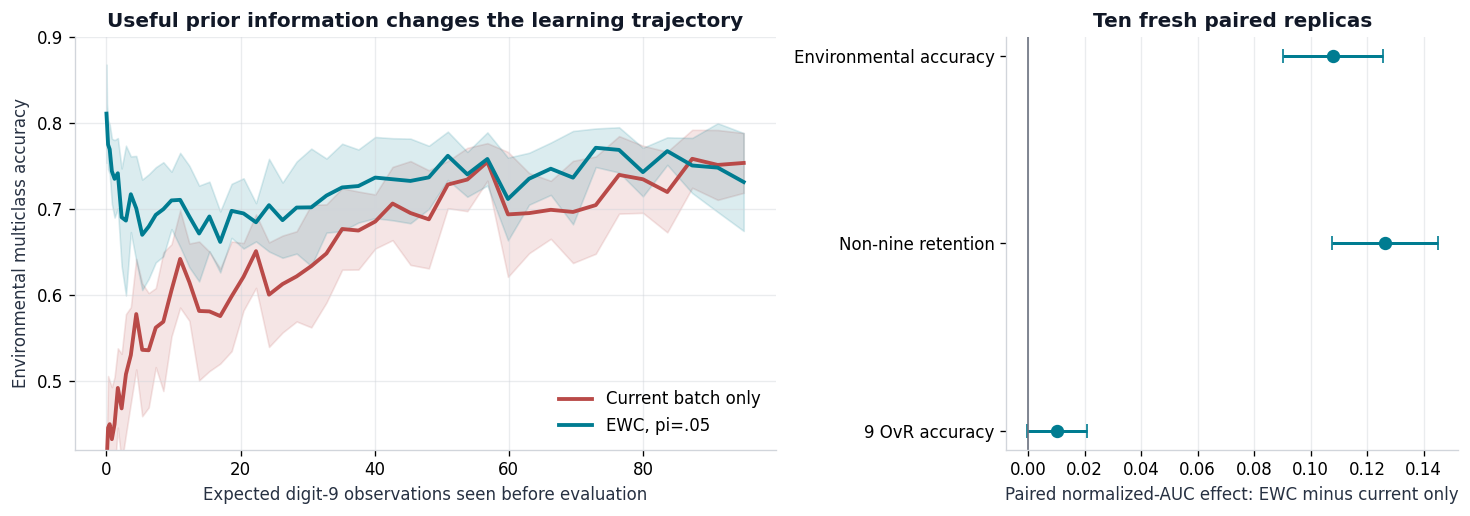

In [2]:
pair = next(
    row
    for row in DEPLOYMENT["paired_auc_differences"]
    if row["treatment"] == "confirm-ewc-fixed005"
    and row["comparison"] == "confirm-current-only"
)

fig, axes = plt.subplots(
    1, 2, figsize=(12.5, 4.4), gridspec_kw={"width_ratios": (1.55, 1)}
)

for condition in ("confirm-current-only", "confirm-ewc-fixed005"):
    plot_expected(axes[0], condition, "environment_accuracy")
axes[0].set(
    xlabel="Expected digit-9 observations seen before evaluation",
    ylabel="Environmental multiclass accuracy",
    title="Useful prior information changes the learning trajectory",
    ylim=(0.42, 0.90),
)
axes[0].legend(loc="lower right")
axes[0].grid(True)

effect_metrics = [
    ("environment_accuracy", "Environmental accuracy"),
    ("non_nine_accuracy", "Non-nine retention"),
    ("nine_ovr_accuracy", "9 OvR accuracy"),
]
y = np.arange(len(effect_metrics))
for position, (metric, label) in enumerate(effect_metrics):
    estimate = pair[metric]
    axes[1].errorbar(
        estimate["mean"],
        position,
        xerr=[[
            estimate["mean"] - estimate["ci95_low"],
        ], [
            estimate["ci95_high"] - estimate["mean"],
        ]],
        fmt="o",
        markersize=7,
        color=COLORS["ewc"],
        capsize=4,
        linewidth=1.8,
    )
axes[1].axvline(0, color="#6B7280", linewidth=1)
axes[1].set(
    yticks=y,
    yticklabels=[label for _, label in effect_metrics],
    xlabel="Paired normalized-AUC effect: EWC minus current only",
    title="Ten fresh paired replicas",
)
axes[1].invert_yaxis()
axes[1].grid(True, axis="x")
fig.tight_layout()
plt.show()

**Key evidence.** Across ten fresh paired replicas, EWC improved environmental-accuracy AUC by **0.1080**, with 95% CI **[0.0902, 0.1258]**. It also improved non-nine accuracy by **0.1262 [0.1074, 0.1451]** and reduced NLL AUC by **6.94 [6.13, 7.75]** in the favorable direction. The direct digit-9 OvR lift was smaller and not individually resolved, which is exactly the expected pattern: EWC's principal contribution is making new learning compatible with retained old capability.

An earlier nested-budget screen bracketed the strict joint Equivalent Data Multiplier at **$(1.96,3.79]$**. In that tested envelope, current-only learning required roughly two to four times the unique digit-9 exposure to match all four target metrics simultaneously. The bracket is evidence of meaningful data efficiency, not a point estimate of a universal multiplier.

**Evidence level:** replicated and confirmatory within this MNIST regime. [Plan 2 evidence](mnist_experiment/plan2.md#phase-5-independent-confirmation) · [Plan 3 fresh confirmation](mnist_experiment/plan3.md#phase-7-analysis-and-next-manifold-handoff)

# Supporting findings

## 1. Lanczos makes a high-value Fisher representation practical

The stored Fisher is modeled as

$$
G \approx D+U\Lambda U^T,
$$

where $D$ is a nonnegative residual diagonal and Lanczos obtains leading Ritz directions using only matrix-vector products. This retains the dominant correlated curvature that a diagonal Fisher cannot represent.

The rank frontier also provides a useful stopping signal. In the copied unreorthogonalized recurrence, ranks above eight lost numerical control after the informative eigenspace had already been swept out. Those outputs are intentionally preserved and labeled unstable. This is not evidence that the true Fisher has rank eight, nor that unstable higher-rank factors should be used.

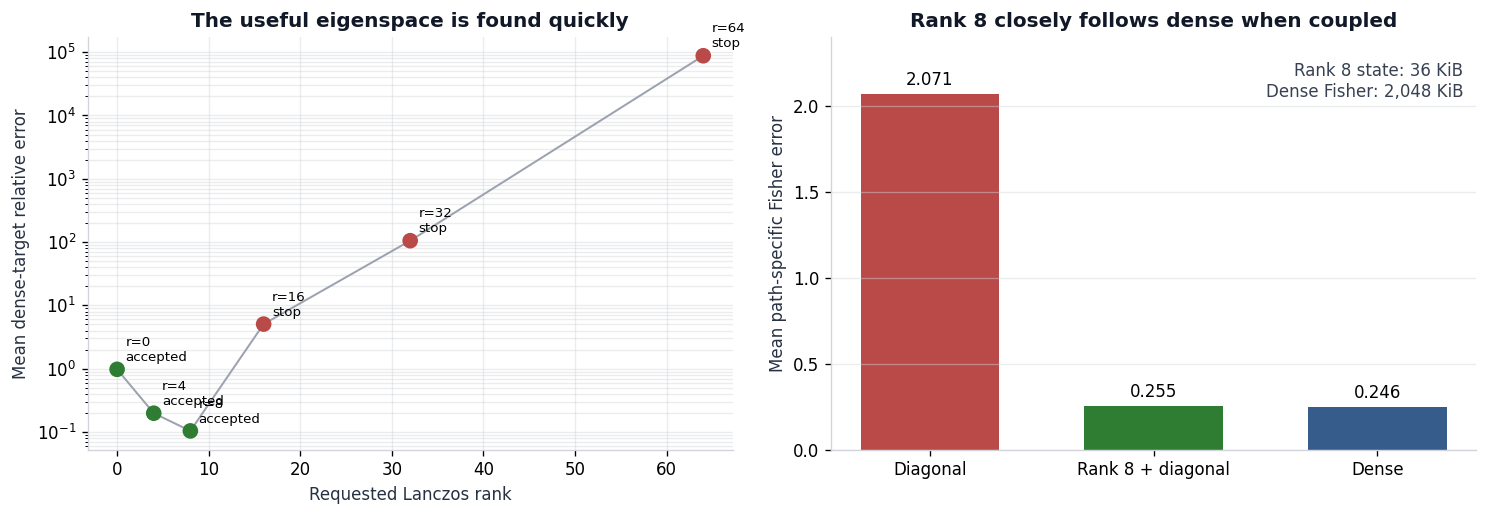

In [3]:
ordered = fixed_summary.sort_values("requested_rank").copy()
accepted = ordered["numerical_status"].eq("completed")
point_colors = np.where(accepted, COLORS["rank8"], COLORS["current"])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].plot(
    ordered["requested_rank"],
    ordered["mean_dense_frobenius_error"],
    color="#9CA3AF",
    linewidth=1.2,
)
axes[0].scatter(
    ordered["requested_rank"],
    ordered["mean_dense_frobenius_error"],
    c=point_colors,
    s=70,
    zorder=3,
)
for _, row in ordered.iterrows():
    label = "accepted" if row["numerical_status"] == "completed" else "stop"
    axes[0].annotate(
        f"r={int(row['requested_rank'])}\n{label}",
        (row["requested_rank"], row["mean_dense_frobenius_error"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )
axes[0].set(
    yscale="log",
    xlabel="Requested Lanczos rank",
    ylabel="Mean dense-target relative error",
    title="The useful eigenspace is found quickly",
)
axes[0].grid(True, which="both")

method_order = [
    "diagonal_ridge_full",
    "low_rank_diagonal_r8",
    "dense_ridge_full",
]
method_labels = ["Diagonal", "Rank 8 + diagonal", "Dense"]
method_colors = [COLORS["diagonal"], COLORS["rank8"], COLORS["dense"]]
values = [
    float(coupled_summary.loc[coupled_summary["method"] == method, "mean_fisher_error"].iloc[0])
    for method in method_order
]
bars = axes[1].bar(method_labels, values, color=method_colors, width=0.62)
axes[1].bar_label(bars, fmt="%.3f", padding=3)
axes[1].set(
    ylabel="Mean path-specific Fisher error",
    title="Rank 8 closely follows dense when coupled",
    ylim=(0, max(values) * 1.16),
)
axes[1].grid(True, axis="y")
axes[1].text(
    0.98, 0.94,
    "Rank 8 state: 36 KiB\nDense Fisher: 2,048 KiB",
    transform=axes[1].transAxes,
    ha="right", va="top", color="#374151",
)
fig.tight_layout()
plt.show()

**Key evidence.** Dense-target error fell from **0.978** for diagonal to **0.198** at rank 4 and **0.104** at rank 8. Rank 8 achieved **0.9999** leading-eigenvector alignment, **0.131** fixed-probe matrix-vector error, and **0.098** EWC quadratic-form error. Its persistent state was **36 KiB**, about 57 times smaller than the dense float64 Fisher.

In the coupled pilot, rank 8 nearly reproduced dense Fisher tracking: mean error **0.255 versus 0.246**, final error **0.0738 versus 0.0722**, and final parameter distance only **0.00490**.

**Evidence level:** a strong numerical and coupled-path pilot, followed by successful use in all later experiments. The direct rank-versus-dense comparison itself has one replica. [Representation notebook](mnist_experiment/representation_results.ipynb) · [Plan 1 representation record](mnist_experiment/plan1.md#phase-7-diagonal-and-low-rank-plus-diagonal-representations)

## 2. The LFU identity survives, but its small-data estimator does not

The derivative identity was validated against a score-only central stencil:

$$
D\mathcal I_\theta[u]=(C_\theta+R_\theta):u,
$$

$$
C_{ijk}=\mathbb E_\theta[s_i s_j s_k],
\qquad
R_{ijk}=\mathbb E_\theta[
(\partial_k s_i)s_j+s_i(\partial_k s_j)].
$$

The failure is operational. Per-step third-moment and Hessian-vector estimates are too noisy, and repeated first-order corrections accumulate error. Direct EMA instead uses the positive empirical Fisher $Z_t$ and avoids the derivative estimate entirely.

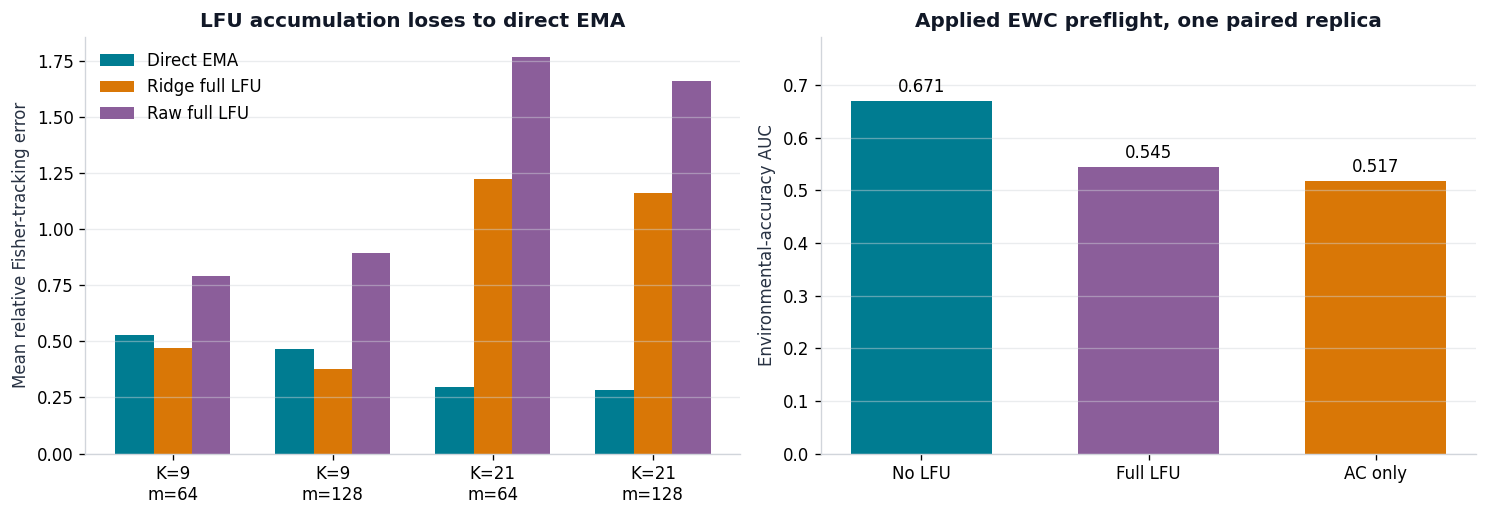

In [4]:
methods = {
    "ema": ("Direct EMA", COLORS["ewc"]),
    "ridge_full_lfu": ("Ridge full LFU", COLORS["ridge"]),
    "full_lfu": ("Raw full LFU", COLORS["lfu"]),
}
cell_order = [(9, 64), (9, 128), (21, 64), (21, 128)]
x = np.arange(len(cell_order))
width = 0.24

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for offset, (method, (label, color)) in zip((-1, 0, 1), methods.items()):
    values = []
    for k, m in cell_order:
        row = lfu_tracking[
            (lfu_tracking["num_p_steps"] == k)
            & (lfu_tracking["samples_per_step"] == m)
            & (lfu_tracking["method"] == method)
        ]
        if len(row) != 1:
            raise RuntimeError(f"Missing unique LFU tracking cell for K={k}, m={m}, {method}")
        values.append(float(row["mean_relative_frobenius_error"].iloc[0]))
    axes[0].bar(x + offset * width, values, width, label=label, color=color)
axes[0].set(
    xticks=x,
    xticklabels=[f"K={k}\nm={m}" for k, m in cell_order],
    ylabel="Mean relative Fisher-tracking error",
    title="LFU accumulation loses to direct EMA",
)
axes[0].legend()
axes[0].grid(True, axis="y")

applied = [
    ("No LFU", NO_LFU_METRICS, COLORS["ewc"]),
    ("Full LFU", FULL_LFU_METRICS, COLORS["lfu"]),
    ("AC only", AC_LFU_METRICS, COLORS["ridge"]),
]
auc_values = [
    normalized_auc_from_control(metrics, "environment_accuracy")
    for _, metrics, _ in applied
]
bars = axes[1].bar(
    [label for label, _, _ in applied],
    auc_values,
    color=[color for _, _, color in applied],
    width=0.62,
)
axes[1].bar_label(bars, fmt="%.3f", padding=3)
axes[1].set(
    ylabel="Environmental-accuracy AUC",
    title="Applied EWC preflight, one paired replica",
    ylim=(0, max(auc_values) * 1.18),
)
axes[1].grid(True, axis="y")
fig.tight_layout()
plt.show()

**Key evidence.** In the realistic 21-step tracking pilot, mean relative error was **0.274** for EMA, **1.733** for raw full LFU, and **1.220** after directional ridge smoothing. Across the $K\times m$ screen, raw LFU was worse than EMA in every cell. Ridge smoothing helped at $K=9$, then lost badly at $K=21$, implicating accumulated correction error.

The later applied preflight was more severe: full-LFU EWC candidates were materially indefinite on **98%** of primary steps and the directional ridge reset on **96%**. Environmental-accuracy AUC fell from **0.671** without LFU to **0.545** with full LFU and **0.517** with AC-only. The remaining LFU replicas were stopped by the predeclared guardrail.

**Conclusion:** retire this online LFU estimator from the practical baseline. The derivative identity itself remains valid, and a future lower-variance estimator could reopen the question. [Tracking analysis](mnist_experiment/results.ipynb) · [LFU isolation record](mnist_experiment/plan3.md#phase-5-lfu-isolation)

## 3. Small replay and compressed Fisher memory are complementary

Pure replay retains recent observations exactly. EWC retains older likelihood information approximately and at constant size. The accepted Hybrid B32 recursion gives every arrival a disjoint lifecycle:

$$
\text{current batch}
\longrightarrow
\text{exact FIFO replay}
\longrightarrow
\text{EWC archive after eviction}.
$$

The archive has its own anchor and never double-counts active replay observations. This asks a practical question rather than forcing one mechanism to win: how much exact short-term memory should sit in front of a compressed long-term summary?

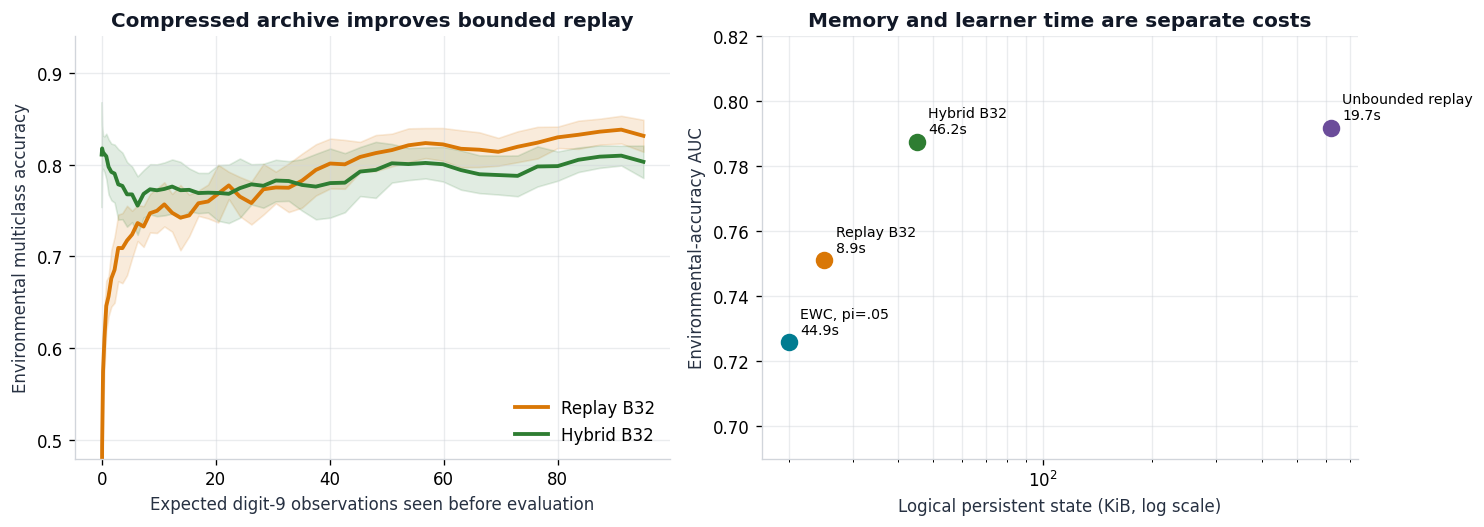

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

for condition in (
    "confirm-replay-b032",
    "confirm-hybrid-b032-fixed005",
):
    plot_expected(axes[0], condition, "environment_accuracy")
axes[0].set(
    xlabel="Expected digit-9 observations seen before evaluation",
    ylabel="Environmental multiclass accuracy",
    title="Compressed archive improves bounded replay",
    ylim=(0.48, 0.94),
)
axes[0].legend(loc="lower right")
axes[0].grid(True)

frontier_conditions = [
    "confirm-ewc-fixed005",
    "confirm-replay-b032",
    "confirm-hybrid-b032-fixed005",
    "confirm-replay-unbounded",
]
auc_by_condition = {
    row["condition"]: row["environment_accuracy"]["mean"]
    for row in DEPLOYMENT["condition_auc"]
}
resource_by_condition = {
    row["condition"]: row
    for row in DEPLOYMENT["resource_summary"]
}
for condition in frontier_conditions:
    resource = resource_by_condition[condition]
    storage_kib = resource["logical_persistent_bytes"]["mean"] / 1024
    accuracy_auc = auc_by_condition[condition]
    learner_seconds = resource["learner_wall_seconds_excluding_evaluation"]["mean"]
    axes[1].scatter(
        storage_kib,
        accuracy_auc,
        s=90,
        color=CONDITION_COLORS[condition],
        zorder=3,
    )
    axes[1].annotate(
        f"{LABELS[condition]}\n{learner_seconds:.1f}s",
        (storage_kib, accuracy_auc),
        xytext=(7, 5),
        textcoords="offset points",
        fontsize=8.5,
    )
axes[1].set(
    xscale="log",
    xlabel="Logical persistent state (KiB, log scale)",
    ylabel="Environmental-accuracy AUC",
    title="Memory and learner time are separate costs",
    ylim=(0.69, 0.82),
)
axes[1].grid(True, which="both")
fig.tight_layout()
plt.show()

**Key evidence.** Across ten fresh paired replicas, Hybrid B32 improved environmental-accuracy AUC over Replay B32 by **0.0365 [0.0177, 0.0552]**. Its digit-9 OvR difference was **-0.0116 [-0.0209, -0.0023]**, inside the predeclared $\pm0.03$ practical-equivalence margin; precision and recall were individually unresolved. Hybrid also added **0.0617 [0.0552, 0.0681]** over EWC alone.

Hybrid B32 and unbounded replay were environmentally tied: **-0.0043 [-0.0245, 0.0158]**. Hybrid used **46,104 bytes** versus **633,624 bytes**, a 13.7-fold reduction, and had substantially better NLL and calibration. Unbounded replay retained higher digit-9 OvR accuracy and precision.

There is a real compute caveat. Mean learner-only time was **46.2 s** for Hybrid B32, **8.9 s** for Replay B32, and **19.7 s** for unbounded replay on this small model. Constant-memory compression is not automatically faster when Fisher estimation and archive consolidation dominate a modest workload.

**Evidence level:** replicated and confirmatory within the tested stream. [Deployment notebook](mnist_experiment/deployment_results.ipynb) · [Plan 3 findings](mnist_experiment/plan3.md#phase-7-analysis-and-next-manifold-handoff)

## 4. Local-risk recommendations for $\pi$ contain signal, but need safer actuation

For the applied quadratic surrogate,

$$
R_t(\pi)=(1-\pi)^2A_t+\pi^2B_t,
\qquad
\pi_t^{\mathrm{loc}}=\frac{A_t}{A_t+B_t}.
$$

This is the exact minimizer of an assumed **one-step local risk**, not a globally optimal continual-learning policy. Exponentially discounted risk (EDR) smooths the estimated coefficients before recommending an action:

$$
\bar A_t=(1-\eta)\bar A_{t-1}+\eta\widehat A_t,
\quad
\bar B_t=(1-\eta)\bar B_{t-1}+\eta\widehat B_t,
\quad
\pi_t^{\mathrm{EDR}}=\frac{\bar A_t}{\bar A_t+\bar B_t}.
$$

The resulting statistic is structured rather than random. The unresolved problem is closed-loop control: transient recommendations change the learner's future path before the estimator settles.

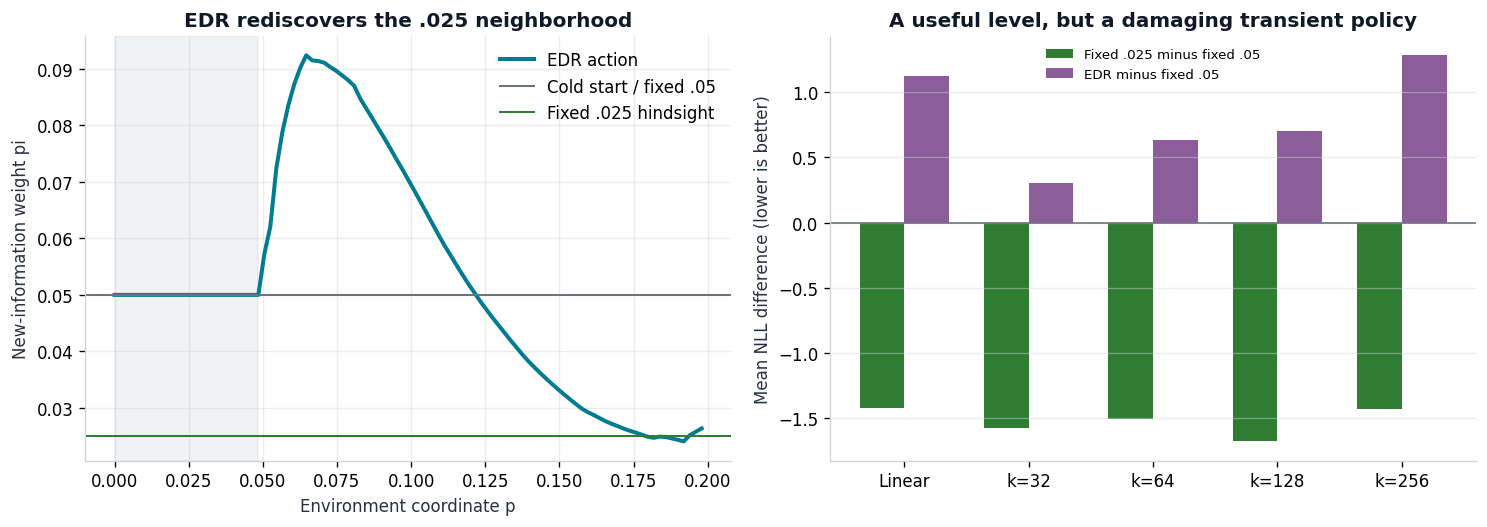

In [6]:
action_name = "edr-fisher-pimin001-h04-cold005"
actions = DISCOVERY["conditions"][action_name]["controller"]["trajectory"]
schedules = ["linear", "logistic-k32", "logistic-k64", "logistic-k128", "logistic-k256"]
display_labels = ["Linear", "k=32", "k=64", "k=128", "k=256"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
p = np.asarray([row["p"] for row in actions], dtype=float)
applied_pi = np.asarray([row["applied_pi"] for row in actions], dtype=float)
axes[0].plot(p, applied_pi, color=COLORS["ewc"], linewidth=2.4, label="EDR action")
axes[0].axhline(0.05, color="#6B7280", linewidth=1.2, label="Cold start / fixed .05")
axes[0].axhline(0.025, color=COLORS["hybrid"], linewidth=1.2, label="Fixed .025 hindsight")
axes[0].axvspan(p[0], p[24], color="#9CA3AF", alpha=0.14)
axes[0].set(
    xlabel="Environment coordinate p",
    ylabel="New-information weight pi",
    title="EDR rediscovers the .025 neighborhood",
)
axes[0].legend(loc="upper right")
axes[0].grid(True)

fixed_nll = [
    FLOOR["schedules"][schedule]["fixed_0025_minus_fixed_005"]["nll"]["full_mean_difference"]
    for schedule in schedules
]
edr_nll = [
    STRESS["schedules"][schedule]["comparisons"]["edr_minus_fixed_005"]["nll"]["full_mean_difference"]
    for schedule in schedules
]
x = np.arange(len(schedules))
width = 0.36
axes[1].bar(
    x - width / 2,
    fixed_nll,
    width,
    color=COLORS["hybrid"],
    label="Fixed .025 minus fixed .05",
)
axes[1].bar(
    x + width / 2,
    edr_nll,
    width,
    color=COLORS["lfu"],
    label="EDR minus fixed .05",
)
axes[1].axhline(0, color="#6B7280", linewidth=1)
axes[1].set(
    xticks=x,
    xticklabels=display_labels,
    ylabel="Mean NLL difference (lower is better)",
    title="A useful level, but a damaging transient policy",
)
axes[1].legend(fontsize=8)
axes[1].grid(True, axis="y")
fig.tight_layout()
plt.show()

**Key evidence.** In the exploratory floor study, fixed $\pi=.025$ descriptively outperformed fixed $.05$ across all five schedules, averaging **+3.86 percentage points** environmental accuracy and **-1.53 NLL**. These schedules share one outer development replica, so this nominates a region rather than confirming a universal value.

Starting from the historically available $.05$, EDR's final ten linear-path actions averaged **0.02501**, with no $.01$ floor clipping. That is meaningful mechanical discovery. Predictive discovery failed: after EDR became live, it produced **+1.488 NLL** and **-4.25 percentage points** environmental accuracy relative to fixed $.05$. On sharper sigmoid paths, the recommendation became increasingly delayed and hysteretic, and closed-loop EDR underperformed fixed $.05$ on every path.

The single-trajectory calibration ratio $C_t$ successfully diagnoses stale residual-risk forecasts as path speed becomes more abrupt, but it cannot certify that an action will improve prediction. The present interpretation is therefore narrow and useful: adaptive $\pi$ is an open recommendation problem with observable signal, not a validated controller.

**Evidence level:** descriptive mechanism evidence from one outer development replica. Independent confirmation requires a redesigned policy. [EDR notebook](mnist_experiment/plan4_edr_results.ipynb) · [Theory Appendix B](mathematical_overview.ipynb) · [Plan 4 decision](mnist_experiment/plan4.md#phase-7-theory-integration-and-historical-decision)

# What survives

| Status | Result |
|---|---|
| **Primary applied finding** | EWC-compressed history materially improves low-data continual learning over current-only optimization. |
| **Practical baseline** | Rank-8-plus-diagonal Fisher, direct EMA, no LFU, fixed $\pi=.05$ on the tested MNIST path. |
| **Strongest constrained strategy** | Hybrid B32: exact short-term replay followed by a disjoint EWC archive. |
| **Retired treatment** | The tested lagged, directional-ridge LFU estimator. Its variance and accumulated correction error outweigh its local derivative information. |
| **Open research direction** | Fisher-risk recommendations for adaptive $\pi_t$, with explicit transient control and predictive safeguards. |

## Boundaries of the evidence

- Every fresh-confirmation initial Fisher used the full 32,768-score budget and still missed the stringent 1% six-sigma Frobenius convergence target. These are high-sample estimates, not exact Fisher controls.
- Rank 8 was directly compared with dense in one coupled replica. Its later reliability is supporting operational evidence, not additional dense-reference replication.
- The LFU conclusion applies to the estimator and low-data regimes tested here. It does not invalidate $D\mathcal I[u]=(C+R):u$.
- The Plan 4 adaptive-$\pi$ schedules share one outer development replica. Their role is hypothesis generation and mechanism diagnosis.
- MNIST is a controlled proxy. The most important next test is a pretrained model facing a genuinely specialized task where old-data replay is expensive and repeated tuning trials are unavailable.

The concise scientific contract is in the [README](README.md). Full provenance and condition definitions are in [EXPERIMENTAL_CONDITIONS.md](mnist_experiment/EXPERIMENTAL_CONDITIONS.md).